# EC back-rotation Test

In [1]:
from dvr import *

In [2]:
# define system parameters
n = 256                      # number of DVR grid points
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
L = 50.0                     # system size

save_plots = True           # save plots or not

gauss_s = lambda r: 2.0 * exp(-((r-3.0)/1.5)**2) # potential

In [3]:
# get exact data
phi_predict = np.linspace(pi/24, pi/6, 20)

test_system = DVR(n, L, rotation_angle=phi, potential=gauss_s)
exact_rrs, exact_energies = [], []
for phi in phi_predict:
    test_system.reset_rotation_angle(phi)
    eigval, eigstate = test_system.closest_to_resonance(real_res)
    rr = test_system.compute_r2(eigstate[:, 0], rotate_rr=True, regulator=False)
    exact_energies.append(eigval[0])
    exact_rrs.append(rr)

# get training data and train EC
phi_train = np.linspace(pi/24, pi/6, 5) # np.random.uniform(pi/24, pi/6, 10)

test_EC = ECSystem(n, L, real_res, potential=gauss_s)
test_EC.train(phi_train)
test_EC.construct_basis()

train_rrs = test_EC.training_rrs
train_energies = test_EC.training_eigvals

# use EC to predict energies and <r^2>
predict_energies, predict_rrs = test_EC.predict(phi_predict, rotate_rr=True)

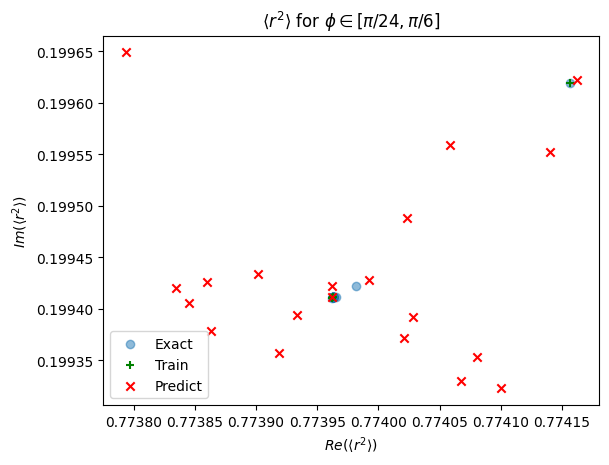

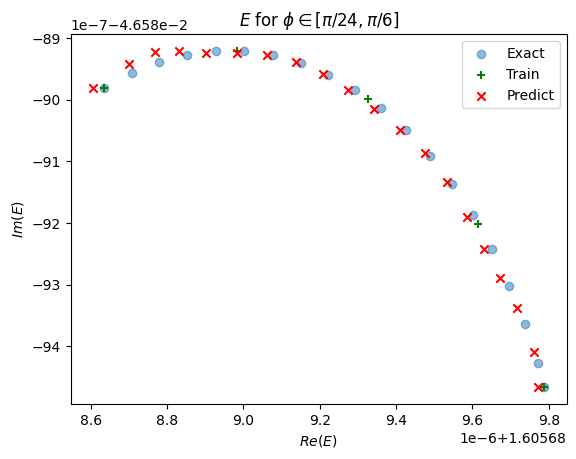

In [4]:
# plot rrs as phi changes
fig, ax = plt.subplots()
ax.scatter(np.real(exact_rrs), np.imag(exact_rrs), alpha=0.5, label="Exact")
ax.scatter(np.real(train_rrs), np.imag(train_rrs), c='green', marker='+', label="Train")
ax.scatter(np.real(predict_rrs), np.imag(predict_rrs), c='red', marker='x', label="Predict")
ax.set_xlabel(r"$Re(\langle r^2\rangle)$")
ax.set_ylabel(r"$Im(\langle r^2\rangle)$")
ax.legend()
ax.set_title(r"$\langle r^2\rangle$ for $\phi\in [\pi/24,\pi/6]$")
if save_plots:
    plt.savefig(f"./plots/ec_radius.png")
plt.show()

fig, ax = plt.subplots()
ax.scatter(np.real(exact_energies), np.imag(exact_energies), alpha=0.5, label=r"Exact")
ax.scatter(np.real(train_energies), np.imag(train_energies), c='green', marker='+', label="Train")
ax.scatter(np.real(predict_energies), np.imag(predict_energies), c='red', marker='x', label="Predict")
ax.set_xlabel(r"$Re(E)$")
ax.set_ylabel(r"$Im(E)$")
ax.set_title(r"$E$ for $\phi\in [\pi/24,\pi/6]$")
ax.legend()
if save_plots:
    plt.savefig(f"./plots/ec_energy.png")
plt.show()

In [5]:
# back-rotate to phi=0 and compute the radius
energy, rr = test_EC.predict([0.0], rotate_rr=False)

print(f"Energy of the back-rotated Gamow resonance: {energy[0].real:.3f} + i{energy[0].imag:.3f}.")
print(f"The <r^2> of the back-rotated Gamow resonance: {rr[0].real:.3f} + i{rr[0].imag:.3f}.")

Energy of the back-rotated Gamow resonance: 1.606 + i-0.046.
The <r^2> of the back-rotated Gamow resonance: 0.798 + i0.191.
